## Imports and Path Setup

In [4]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import SimpleITK as sitk
import recon_plot_helpers

### Load $\lambda$, $z_k$, MVF

In [5]:
## 1. Select gate to load (gate = 0 is reference)
gate = 4

## Base directory where everything is located - MUST CHANGE
base_dir = f"/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files"

## Lambda = motion corrected image
lam_path = os.path.join(base_dir,"lam.nii")
z_gate_path = os.path.join(base_dir, f"z{gate}.nii")

## Load MVF and MVF inverse
mvf_lam_to_z = os.path.join(base_dir, f"mvf_lam_to_z{gate}.nii")
mvf_z_to_lam = os.path.join(base_dir, f"mvf_z{gate}_to_lam.nii")

## 1. View $\lambda$, $z_k$

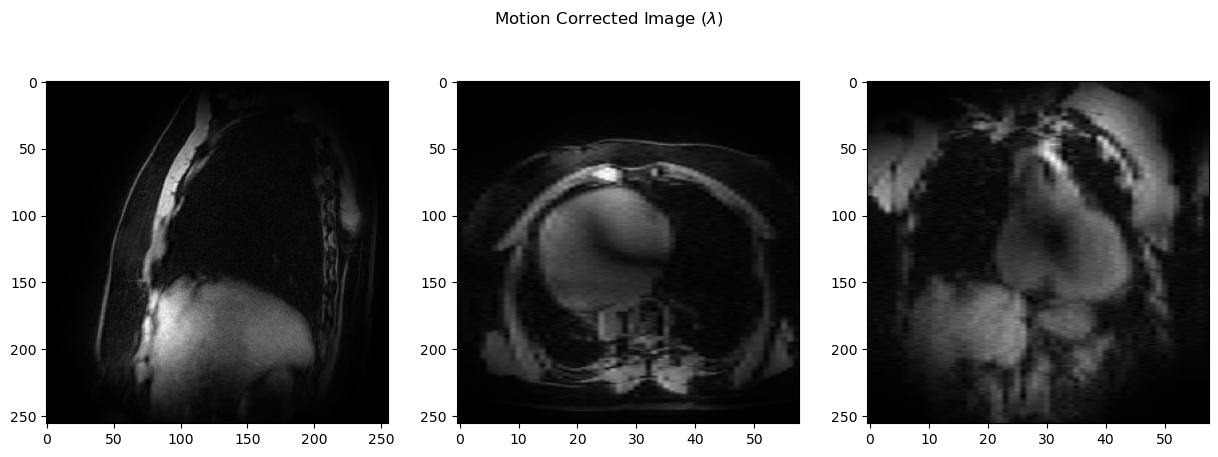

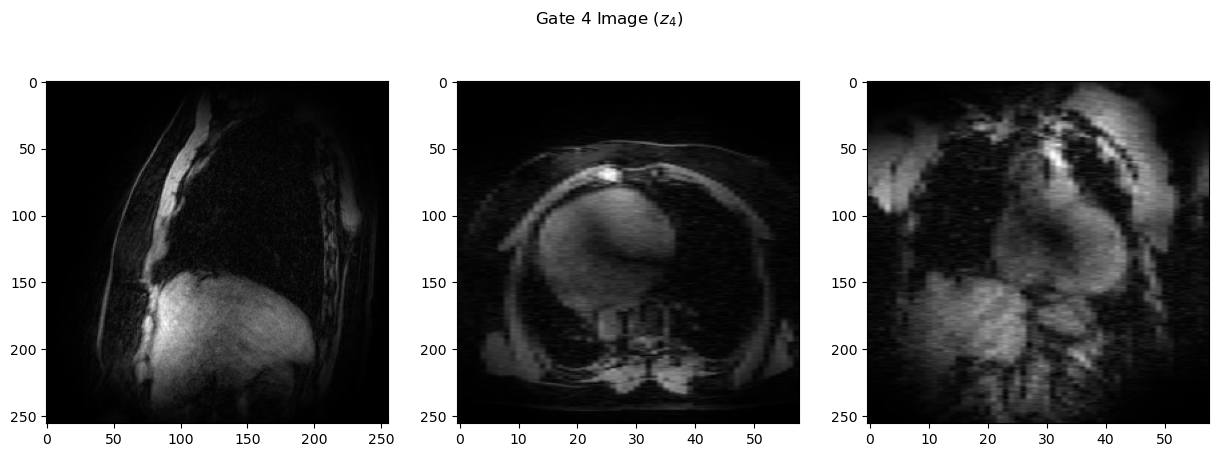

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [6]:
ref_img = sitk.GetArrayFromImage(sitk.ReadImage(lam_path))
gate_img = sitk.GetArrayFromImage(sitk.ReadImage(z_gate_path))
z_idx = 44
## 1. Reference
recon_plot_helpers.plot_recons_all_axes(ref_img, z_idx = z_idx, title=rf"Motion Corrected Image ($\lambda$)")
## 2. Gate
recon_plot_helpers.plot_recons_all_axes(gate_img, z_idx= z_idx, title=rf"Gate {gate} Image ($z_{gate}$)")

## 2.  Apply deformation fields

In [7]:
def apply_warp_sitk(image_path, field_path, save=False, output_path=None):
    '''
    Input
    -----------------------
    image_path: path
        Filepath of input image (.nii)
    field_path: path
        Filepath of MVF (.nii)

    Output
    ------------------------
    warped_img: ITK Image object
        Result image of MVF applied to the input image

    '''
    ## 1. Load the image and the displacement field
    moving_img = sitk.ReadImage(image_path)
    field = sitk.ReadImage(field_path)

    ## 2. Convert the displacement field to a Transform object
    # SimpleITK expects the field to be in mm and physical space
    transform = sitk.DisplacementFieldTransform(sitk.Cast(field, sitk.sitkVectorFloat64))

    ## 3. Resample (Warp)
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(moving_img) # Output grid
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetTransform(transform)
    
    warped_img = resampler.Execute(moving_img)

    ## 4. Save
    if save:
        if output_path is None:
            ValueError("Must provide output_path to save.")
        else:
            sitk.WriteImage(warped_img, output_path)
            print(f"Warped image saved to {output_path}")

    return warped_img

def plot_warping_verification(fixed, moving, warped, gate, z_idx=None, y_idx=None, x_idx=None, title="Warping Verification"):
    """
    fixed, moving, warped: 3D numpy arrays (Nz, Ny, Nx)
    """
    images = [fixed, moving, warped]
    names = [rf'Fixed ($\lambda$ = Target)', rf'Moving ($z_{gate}$ = Source)', rf'Warped ($M^{{-1}}(z_{gate}) = \lambda$)']
    
    Nz, Ny, Nx = fixed.shape
    if z_idx is None: z_idx = 44
    if y_idx is None: y_idx = Ny // 2
    if x_idx is None: x_idx = Nx // 2

    # We also calculate the difference to see residuals
    diff_before = fixed - moving
    diff_after = fixed - warped
    
    fig, axs = plt.subplots(3, 4, figsize=(20, 15))
    
    for i, img in enumerate(images + [diff_after]):
        col_name = names[i] if i < 3 else rf"Difference (Fixed - Warped $\approx$ 0)"
        
        # --- Axial ---
        ax_img = np.fliplr(img[z_idx, :, :])
        im0 = axs[0, i].imshow(ax_img, cmap='gray' if i < 3 else 'RdBu', aspect=Ny/Nx)
        axs[0, i].set_title(f"{col_name}")
        
        # --- Coronal ---
        cor_img = np.rot90(img[:, y_idx, :], k=-3)
        axs[1, i].imshow(cor_img, cmap='gray' if i < 3 else 'RdBu', aspect=Nz/Nx)
        # axs[1, i].set_title("Coronal")
        
        # --- Sagittal ---
        sag_img = np.rot90(img[:, :, x_idx], k=-1)
        axs[2, i].imshow(sag_img, cmap='gray' if i < 3 else 'RdBu', aspect=Nz/Ny)
        # axs[2, i].set_title("Sagittal")

    # Add colorbar for the difference column only
    plt.colorbar(im0, ax=axs[:, 3], shrink=0.6)

    fig.suptitle(title, fontsize=20)
    # plt.tight_layout()
    plt.show()


## Returns Image object
warped_z_to_lam= apply_warp_sitk(z_gate_path, mvf_z_to_lam)

lam_img = sitk.GetArrayFromImage(sitk.ReadImage(lam_path))
z_img = sitk.GetArrayFromImage(sitk.ReadImage(z_gate_path))
warped_z_to_lam_img = sitk.GetArrayFromImage(warped_z_to_lam)

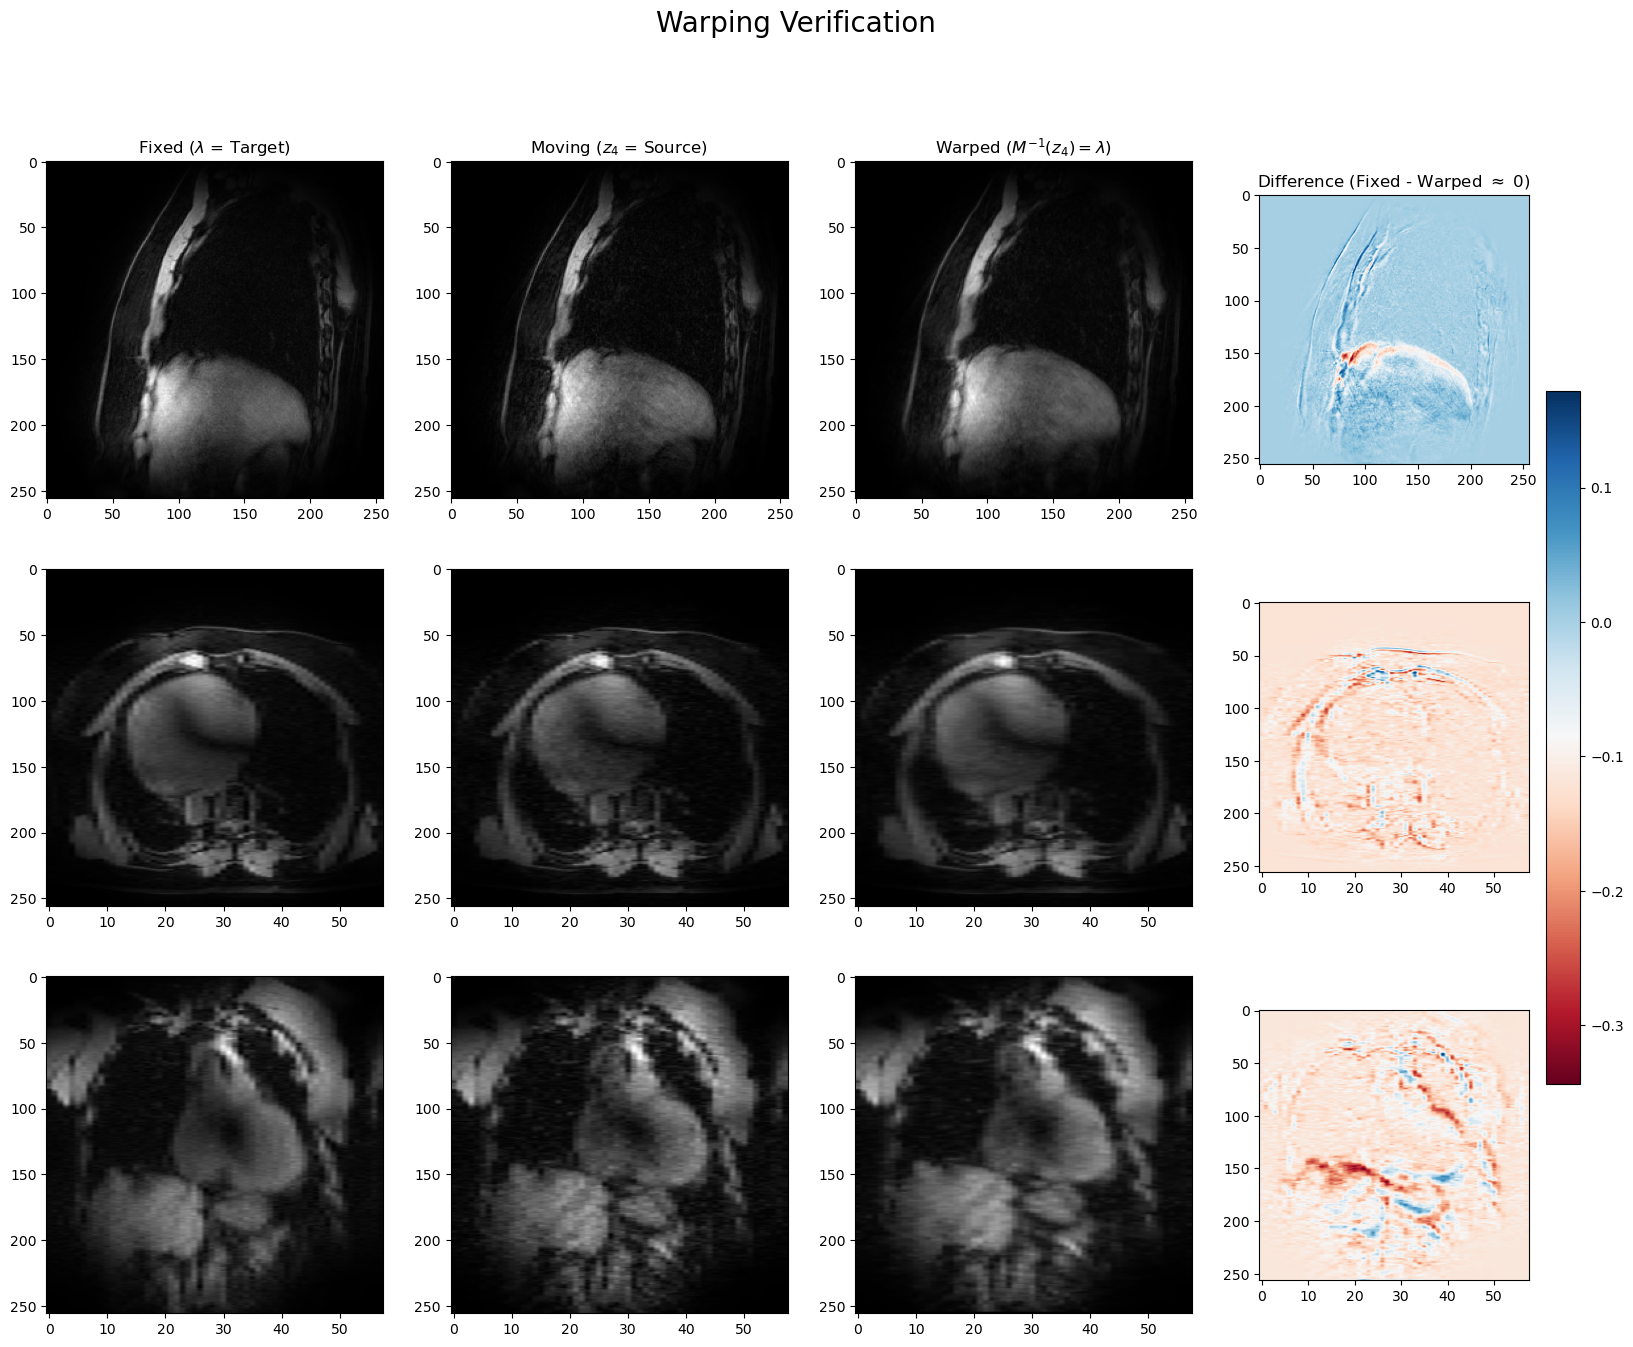

In [8]:
plot_warping_verification(lam_img, z_img, warped_z_to_lam_img, gate=gate, z_idx=z_idx)